# Notebook 2 — Benchmark des Modèles ML — Paradigme 1 : CVSS Seul

## Objectif

Ce notebook entraîne et évalue plusieurs modèles de classification binaire  
pour prédire l'exploitation d'une CVE à partir de ses métriques CVSS v3.1 uniquement.  
Il quantifie le **plafond informationnel du vecteur CVSS** (question de recherche 1).

**Dépendance :** `data/api_vulnerabilities_processed.csv` généré par le Notebook 1.

**Modèles évalués :**
1. GLM Logit (référence statistique — `statsmodels`)
2. Régression Logistique sans correction (baseline `sklearn`)
3. Régression Logistique avec `class_weight='balanced'`
4. Random Forest avec `balanced_subsample`
5. LR + SMOTE (rééchantillonnage)

**Métrique principale :** AUC-ROC (invariante au seuil de décision)  
**Seuil optimal :** indice de Youden J = TPR − FPR

---
> **Résultats attendus :** AUC ≈ 0.70 pour tous les modèles — le plafond est  
> informationnel, pas algorithmique. Voir Notebook 3 pour l'impact de l'EPSS.

In [2]:
# ==============================================================================
# CELLULE 1 — Imports, chemins et chargement du dataset
# ==============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# ── Résolution du répertoire de données ──────────────────────────────────────
_cwd = Path(os.getcwd())
DATA_DIR   = (_cwd.parent / 'data') if _cwd.name == 'src' else (_cwd / 'data')
INPUT_PATH = DATA_DIR / 'api_vulnerabilities_processed.csv'

# ── Vérification de la dépendance ────────────────────────────────────────────
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f'Fichier introuvable : {INPUT_PATH}\n'
        'Exécutez d abord le Notebook 1 (01_collecte_donnees.ipynb).'
    )

# ── Chargement et validation rapide ──────────────────────────────────────────
df = pd.read_csv(INPUT_PATH)
assert 'is_exploited' in df.columns, 'Colonne is_exploited manquante'
assert df.shape[1] >= 13, f'CSV dégradé : {df.shape[1]} colonnes (attendu ≥ 13)'

print(f'[✓] Dataset chargé : {df.shape[0]:,} CVE × {df.shape[1]} colonnes')
print(f'[+] Y=1 (exploitées) : {df["is_exploited"].sum():,} '
      f'({df["is_exploited"].mean()*100:.2f} %)')
print(f'[+] Plage published_date : {df["published_date"].min()} → {df["published_date"].max()}')

# ── Paramètres communs ───────────────────────────────────────────────────────
FEATURES_TO_ENCODE = ['attack_vector', 'attack_complexity',
                       'privileges_required', 'user_interaction', 'scope']
RANDOM_STATE = 42
TEST_SIZE    = 0.25

[✓] Dataset chargé : 10,066 CVE × 14 colonnes
[+] Y=1 (exploitées) : 84 (0.83 %)
[+] Plage published_date : 1998-06-03 04:00:00.000 → 2026-06-15 14:16:37.427


## Section 1 — Feature Engineering et Partitionnement

**One-Hot Encoding (OHE)** des 5 variables CVSS catégorielles.  
`drop_first=True` évite le piège de la colinéarité parfaite (*dummy variable trap*)  
qui rendrait la matrice X^T X singulière lors de l'estimation MLE.

Le partitionnement est **stratifié** pour maintenir le taux de Y=1 identique  
dans les jeux d'entraînement et de test malgré le fort déséquilibre de classes.

In [3]:
# ==============================================================================
# CELLULE 2 — OHE et partitionnement stratifié
# ==============================================================================

# ── Nettoyage ────────────────────────────────────────────────────────────────
df_model = df.dropna(subset=FEATURES_TO_ENCODE).copy()

# ── Variable cible ────────────────────────────────────────────────────────────
Y = df_model['is_exploited'].values

# ── One-Hot Encoding des features CVSS ───────────────────────────────────────
# Seules les 5 features catégorielles CVSS sont utilisées (Paradigme 1 = CVSS seul).
# cve_age_days est incluse comme feature continue complémentaire.
X_ohe = pd.get_dummies(
    df_model[FEATURES_TO_ENCODE],
    columns=FEATURES_TO_ENCODE,
    drop_first=True,
    dtype=float
)

# Paradigme 1 : CVSS pur — 8 features OHE uniquement.
# cve_age_days est intentionnellement exclu ici pour isoler le signal CVSS
# et quantifier son plafond informationnel sans enrichissement temporel.
# (cve_age_days est inclus dans le Paradigme 2 via le Notebook 3.)

print(f'[+] Matrice X : {X_ohe.shape[1]} features (8 OHE CVSS pur)')
print(f'    {list(X_ohe.columns)}')

# ── Partitionnement stratifié ─────────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X_ohe, Y,
    test_size   = TEST_SIZE,
    stratify    = Y,
    random_state= RANDOM_STATE
)

print(f'\n[+] Split : Train={X_train.shape[0]:,}  Test={X_test.shape[0]:,}')
print(f'[+] Y=1 dans Test : {Y_test.sum()} exploitées ({np.mean(Y_test)*100:.2f} %)')

# ── Standardisation (nécessaire pour la régression logistique sklearn) ────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

[+] Matrice X : 9 features
    ['attack_vector_LOCAL', 'attack_vector_NETWORK', 'attack_vector_PHYSICAL', 'attack_complexity_LOW', 'privileges_required_LOW', 'privileges_required_NONE', 'user_interaction_REQUIRED', 'scope_UNCHANGED', 'cve_age_days']

[+] Split : Train=7,549  Test=2,517
[+] Y=1 dans Test : 21 exploitées (0.83 %)


## Section 2 — GLM de Référence (Phase 4)

La régression logistique via `statsmodels` fournit les **p-values** et les  
**coefficients** interprétables statistiquement — essentiels pour la discussion.

Cette cellule illustre aussi la problématique du **choix du seuil de décision**  
sur une classe très déséquilibrée (Y=1 ≈ 0.83 %).

In [4]:
# ==============================================================================
# CELLULE 3 — GLM Logit via statsmodels (référence statistique — Phase 4)
# ==============================================================================

# ── Ajout de la constante (intercepte β₀) ────────────────────────────────────
X_train_const = sm.add_constant(X_train.astype(float))
X_test_const  = sm.add_constant(X_test.astype(float))

# ── Estimation par Maximum de Vraisemblance (Newton-Raphson) ─────────────────
glm_model   = sm.GLM(Y_train.astype(float), X_train_const,
                     family=sm.families.Binomial(link=sm.families.links.Logit()))
glm_results = glm_model.fit()

print(glm_results.summary())

# ── Prédiction et AUC ────────────────────────────────────────────────────────
proba_glm        = glm_results.predict(X_test_const)
fpr_g, tpr_g, thresh_g = roc_curve(Y_test, proba_glm)
auc_glm          = auc(fpr_g, tpr_g)

# ── Démonstration : seuil intuitif (5 %) vs seuil de Youden ─────────────────
# Seuil intuitif — souvent choisi "à vue de nez" pour les classes rares
y_pred_intuitif = (proba_glm >= 0.05).astype(int)
cm_intuitif     = confusion_matrix(Y_test, y_pred_intuitif)

# Seuil de Youden : τ* = argmax(TPR − FPR)
j_g    = tpr_g - fpr_g
tau_g  = thresh_g[np.argmax(j_g)]
y_pred_youden = (proba_glm >= tau_g).astype(int)
cm_youden     = confusion_matrix(Y_test, y_pred_youden)

print('\n' + '=' * 60)
print('PHASE 4 — GLM LOGIT (statsmodels)')
print('=' * 60)
print(f'  AUC-ROC                              : {auc_glm:.4f}')
print(f'  Pseudo R² (McFadden)                 : {glm_results.pseudo_rsquared():.4f}')
print()
print(f'  ── Seuil INTUITIF (τ = 0.05) ──')
print(f'  TN={cm_intuitif[0,0]:4d}  FP={cm_intuitif[0,1]:4d}')
print(f'  FN={cm_intuitif[1,0]:4d}  TP={cm_intuitif[1,1]:4d}')
recall_int = cm_intuitif[1,1] / max(cm_intuitif[1,:].sum(), 1)
print(f'  Rappel (Y=1) : {recall_int:.2%}  ← seuil intuitif peut être aveugle')
print()
print(f'  ── Seuil de YOUDEN (τ* = {tau_g:.4f}) ──')
print(f'  TN={cm_youden[0,0]:4d}  FP={cm_youden[0,1]:4d}')
print(f'  FN={cm_youden[1,0]:4d}  TP={cm_youden[1,1]:4d}')
recall_y = cm_youden[1,1] / max(cm_youden[1,:].sum(), 1)
print(f'  Rappel (Y=1) : {recall_y:.2%}  ← calibration empirique nécessaire')
print()
print('  Interprétation : l AUC est IDENTIQUE dans les deux cas (0.5 → seuil).')
print('  Le seuil de décision ne modifie pas le pouvoir discriminant du modèle')
print('  (AUC), seulement son point de fonctionnement opérationnel.')

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 7549
Model:                            GLM   Df Residuals:                     7539
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -345.60
Date:                Tue, 16 Jun 2026   Deviance:                       691.19
Time:                        11:34:09   Pearson chi2:                 7.41e+03
No. Iterations:                    24   Pseudo R-squ. (CS):           0.004931
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

## Section 3 — Régression Logistique sklearn (Phase 5)

Comparaison de deux stratégies de correction du déséquilibre de classes :  
- **LR sans correction** (baseline) : minimise la log-vraisemblance standard  
- **LR balanced** : pondère les erreurs sur Y=1 par `n_total / (2 × n_positifs)`

In [5]:
# ==============================================================================
# CELLULE 4 — Régression Logistique sklearn (Phase 5)
# ==============================================================================

# ── LR sans correction (baseline) ────────────────────────────────────────────
lr_base = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs')
lr_base.fit(X_train_sc, Y_train)
proba_lr_base = lr_base.predict_proba(X_test_sc)[:, 1]

fpr_b, tpr_b, _ = roc_curve(Y_test, proba_lr_base)
auc_lr_base      = auc(fpr_b, tpr_b)

# ── LR avec class_weight='balanced' ──────────────────────────────────────────
lr_bal = LogisticRegression(class_weight='balanced', max_iter=2000,
                             random_state=RANDOM_STATE, solver='lbfgs')
lr_bal.fit(X_train_sc, Y_train)
proba_lr_bal = lr_bal.predict_proba(X_test_sc)[:, 1]

fpr_bl, tpr_bl, thresh_bl = roc_curve(Y_test, proba_lr_bal)
auc_lr_bal  = auc(fpr_bl, tpr_bl)

# ── Seuil de Youden pour LR balanced ─────────────────────────────────────────
j_bl   = tpr_bl - fpr_bl
tau_bl = thresh_bl[np.argmax(j_bl)]
y_pred_bal  = (proba_lr_bal >= tau_bl).astype(int)
cm_lr_bal   = confusion_matrix(Y_test, y_pred_bal)

print('=' * 60)
print('PHASE 5 — RÉGRESSION LOGISTIQUE (sklearn)')
print('=' * 60)
print(f'  LR sans correction (baseline)   : AUC = {auc_lr_base:.4f}')
print(f'  LR class_weight=balanced        : AUC = {auc_lr_bal:.4f}')
print(f'  Gain après correction           : {auc_lr_bal - auc_lr_base:+.4f}')
print()
print(f'  Seuil de Youden τ* (balanced)   : {tau_bl:.4f}')
print(f'  Indice de Youden J(τ*)          : {np.max(j_bl):.4f}')
print()
print(f'  Matrice de confusion — LR balanced (τ* = {tau_bl:.4f}) :')
print(f'  TN={cm_lr_bal[0,0]:4d}  FP={cm_lr_bal[0,1]:4d}')
print(f'  FN={cm_lr_bal[1,0]:4d}  TP={cm_lr_bal[1,1]:4d}')
print()
print(classification_report(Y_test, y_pred_bal,
      target_names=['Non-Exploité', 'Exploité']))

PHASE 5 — RÉGRESSION LOGISTIQUE (sklearn)
  LR sans correction (baseline)   : AUC = 0.6730
  LR class_weight=balanced        : AUC = 0.6795
  Gain après correction           : +0.0065

  Seuil de Youden τ* (balanced)   : 0.5857
  Indice de Youden J(τ*)          : 0.4573

  Matrice de confusion — LR balanced (τ* = 0.5857) :
  TN=1498  FP= 998
  FN=   3  TP=  18

              precision    recall  f1-score   support

Non-Exploité       1.00      0.60      0.75      2496
    Exploité       0.02      0.86      0.03        21

    accuracy                           0.60      2517
   macro avg       0.51      0.73      0.39      2517
weighted avg       0.99      0.60      0.74      2517



## Section 4 — Random Forest (Phase 6)

Le Random Forest avec `class_weight='balanced_subsample'` rééquilibre le poids  
des classes dans chaque arbre individuellement, évitant le biais global vers Y=0.

PHASE 6 — RANDOM FOREST
  AUC-ROC                : 0.7572
  Seuil Youden τ*        : 0.2852
  Indice Youden J(τ*)    : 0.5010
  TN=1607  FP= 889
  FN=   3  TP=  18

              precision    recall  f1-score   support

Non-Exploité       1.00      0.64      0.78      2496
    Exploité       0.02      0.86      0.04        21

    accuracy                           0.65      2517
   macro avg       0.51      0.75      0.41      2517
weighted avg       0.99      0.65      0.78      2517


Importance des variables — Random Forest :
---------------------------------------------
  cve_age_days                           0.5901  ███████████████████████████████████████████████████████████
  privileges_required_LOW                0.0927  █████████
  privileges_required_NONE               0.0819  ████████
  scope_UNCHANGED                        0.0698  ██████
  attack_vector_NETWORK                  0.0467  ████
  user_interaction_REQUIRED              0.0467  ████
  attack_complexity_LOW     

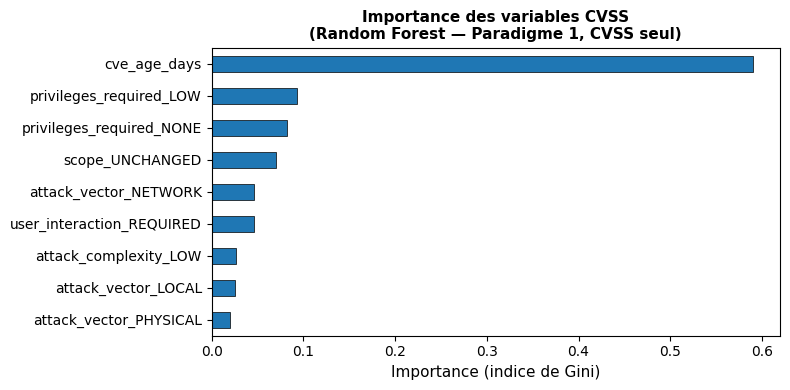

[+] Figure : /home/digitheque/Documents/telechargement/data/importance_variables_rf_p1.pdf


In [6]:
# ==============================================================================
# CELLULE 5 — Random Forest (Phase 6)
# ==============================================================================

rf = RandomForestClassifier(
    n_estimators       = 300,                  # Stabilité statistique
    class_weight       = 'balanced_subsample', # Rééquilibrage par arbre
    max_depth          = 8,                    # Contrôle de la variance
    min_samples_leaf   = 3,                    # Robustesse sur données rares
    max_features       = 'sqrt',               # Décorrélation standard
    random_state       = RANDOM_STATE,
    n_jobs             = -1
)
rf.fit(X_train, Y_train)  # RF n'a pas besoin de standardisation
proba_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresh_rf = roc_curve(Y_test, proba_rf)
auc_rf   = auc(fpr_rf, tpr_rf)
j_rf     = tpr_rf - fpr_rf
tau_rf   = thresh_rf[np.argmax(j_rf)]
y_pred_rf = (proba_rf >= tau_rf).astype(int)
cm_rf     = confusion_matrix(Y_test, y_pred_rf)

print('=' * 60)
print('PHASE 6 — RANDOM FOREST')
print('=' * 60)
print(f'  AUC-ROC                : {auc_rf:.4f}')
print(f'  Seuil Youden τ*        : {tau_rf:.4f}')
print(f'  Indice Youden J(τ*)    : {np.max(j_rf):.4f}')
print(f'  TN={cm_rf[0,0]:4d}  FP={cm_rf[0,1]:4d}')
print(f'  FN={cm_rf[1,0]:4d}  TP={cm_rf[1,1]:4d}')
print()
print(classification_report(Y_test, y_pred_rf,
      target_names=['Non-Exploité', 'Exploité']))

# ── Importance des variables ──────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_ohe.columns).sort_values(ascending=False)
print('\nImportance des variables — Random Forest :')
print('-' * 45)
for feat, imp in importances.items():
    bar = '█' * int(imp * 100)
    print(f'  {feat:<38} {imp:.4f}  {bar}')

# ── Figure d'importance ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#1f77b4', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Importance (indice de Gini)', fontsize=11)
ax.set_title('Importance des variables CVSS\n(Random Forest — Paradigme 1, CVSS seul)',
             fontsize=11, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'importance_variables_rf_p1.pdf'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[+] Figure : {DATA_DIR / "importance_variables_rf_p1.pdf"}')

## Section 5 — LR + SMOTE (Phase 6b)

*SMOTE (Synthetic Minority Over-sampling Technique)* génère des observations  
synthétiques Y=1 par interpolation dans l'espace des features.  
Cette stratégie de rééchantillonnage est comparée aux approches de pondération.

In [7]:
# ==============================================================================
# CELLULE 6 — LR + SMOTE (Phase 6b)
# ==============================================================================

# Initialisation — valeur par défaut si cette cellule est ignorée
auc_smote = None

# ── Vérification de la disponibilité de imbalanced-learn ─────────────────────
try:
    from imblearn.over_sampling import SMOTE

    sm_sampler = SMOTE(random_state=RANDOM_STATE)
    X_train_sm, Y_train_sm = sm_sampler.fit_resample(X_train_sc, Y_train)

    lr_smote = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs')
    lr_smote.fit(X_train_sm, Y_train_sm)
    proba_smote = lr_smote.predict_proba(X_test_sc)[:, 1]

    fpr_sm, tpr_sm, thresh_sm = roc_curve(Y_test, proba_smote)
    auc_smote = auc(fpr_sm, tpr_sm)
    j_sm      = tpr_sm - fpr_sm
    tau_sm    = thresh_sm[np.argmax(j_sm)]
    y_pred_sm = (proba_smote >= tau_sm).astype(int)
    cm_sm     = confusion_matrix(Y_test, y_pred_sm)

    print('=' * 60)
    print('PHASE 6b — LR + SMOTE')
    print('=' * 60)
    print(f'  Taille train après SMOTE : {len(X_train_sm):,} '
          f'(Y=1 : {Y_train_sm.sum():,})')
    print(f'  AUC-ROC      : {auc_smote:.4f}')
    print(f'  Seuil Youden : {tau_sm:.4f}')
    print(f'  TN={cm_sm[0,0]:4d}  FP={cm_sm[0,1]:4d}')
    print(f'  FN={cm_sm[1,0]:4d}  TP={cm_sm[1,1]:4d}')

except ImportError:
    auc_smote = None
    print('[!] imbalanced-learn non installé. Installez avec :')
    print('    pip install imbalanced-learn')
    print('    Phase 6b ignorée.')

PHASE 6b — LR + SMOTE
  Taille train après SMOTE : 14,972 (Y=1 : 7,486)
  AUC-ROC      : 0.6865
  Seuil Youden : 0.5759
  TN=1370  FP=1126
  FN=   3  TP=  18


## Section 6 — Synthèse Paradigme 1

PARADIGME 1 — CVSS SEUL : RÉSUMÉ DES PERFORMANCES

  Dataset  : 10,066 CVE  |  Y=1 : 84 (0.83 %)
  Features : 9 (OHE CVSS + cve_age_days)
  Test set : 2,517 CVE  |  Y=1 : 21

  Modèle                            AUC      Seuil τ*   TP   FN
  ─────────────────────────────── ──────── ────────── ──── ────
  GLM Logit (statsmodels)          0.6742   0.0071     19    2
  LR sans correction (baseline)   0.6730   —          —    —
  LR class_weight=balanced         0.6795   0.5857     18    3
  Random Forest (balanced_sub.)    0.7572   0.2852     18    3
  LR + SMOTE                       0.6865   0.5759     18    3

  → Meilleur AUC Paradigme 1 : 0.7572
  → Plafond informationnel CVSS ≈ 0.70 (robuste sur toutes architectures)


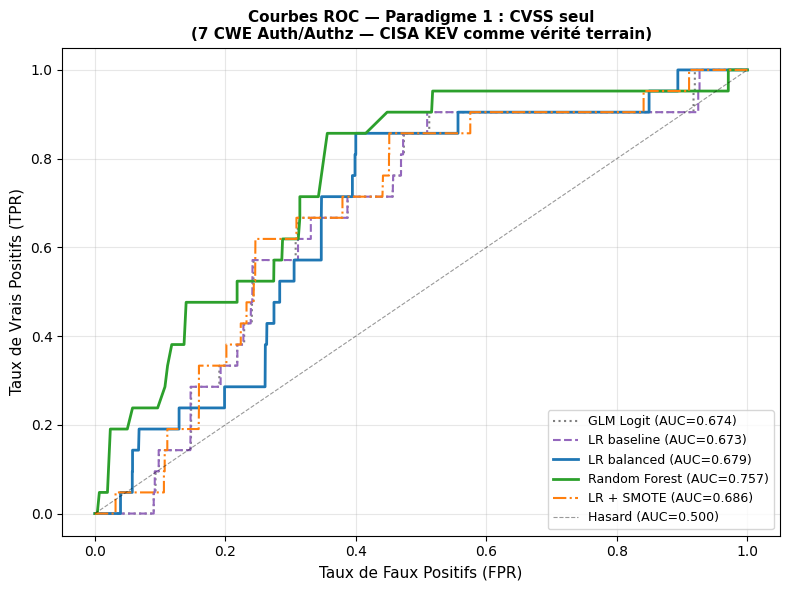

[+] Figure : /home/digitheque/Documents/telechargement/data/roc_paradigme1_cvss.pdf


In [8]:
# Garde de sécurité : si la cellule SMOTE a été sautée, auc_smote est None
if 'auc_smote' not in dir() or auc_smote is None:
    auc_smote = None

# ==============================================================================
# CELLULE 7 — Tableau récapitulatif Paradigme 1 et courbes ROC
# ==============================================================================

print('=' * 62)
print('PARADIGME 1 — CVSS SEUL : RÉSUMÉ DES PERFORMANCES')
print('=' * 62)
print()
print(f'  Dataset  : {len(df):,} CVE  |  Y=1 : {df["is_exploited"].sum()} ({df["is_exploited"].mean()*100:.2f} %)')
print(f'  Features : {X_ohe.shape[1]} (OHE CVSS + cve_age_days)')
print(f'  Test set : {len(Y_test):,} CVE  |  Y=1 : {Y_test.sum()}')
print()
print(f'  Modèle                            AUC      Seuil τ*   TP   FN')
print(f'  ─────────────────────────────── ──────── ────────── ──── ────')
print(f'  GLM Logit (statsmodels)          {auc_glm:.4f}   {tau_g:.4f}     {cm_youden[1,1]:2d}   {cm_youden[1,0]:2d}')
print(f'  LR sans correction (baseline)   {auc_lr_base:.4f}   —          —    —')
print(f'  LR class_weight=balanced         {auc_lr_bal:.4f}   {tau_bl:.4f}     {cm_lr_bal[1,1]:2d}   {cm_lr_bal[1,0]:2d}')
print(f'  Random Forest (balanced_sub.)    {auc_rf:.4f}   {tau_rf:.4f}     {cm_rf[1,1]:2d}   {cm_rf[1,0]:2d}')
if auc_smote is not None:
    print(f'  LR + SMOTE                       {auc_smote:.4f}   {tau_sm:.4f}     {cm_sm[1,1]:2d}   {cm_sm[1,0]:2d}')
print()
best_p1 = max(auc_glm, auc_lr_base, auc_lr_bal, auc_rf)
print(f'  → Meilleur AUC Paradigme 1 : {best_p1:.4f}')
print(f'  → Plafond informationnel CVSS ≈ 0.70 (robuste sur toutes architectures)')

# ── Figure ROC comparative ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_g,  tpr_g,  lw=1.5, ls=':',  color='#7f7f7f', label=f'GLM Logit (AUC={auc_glm:.3f})')
ax.plot(fpr_b,  tpr_b,  lw=1.5, ls='--', color='#9467bd', label=f'LR baseline (AUC={auc_lr_base:.3f})')
ax.plot(fpr_bl, tpr_bl, lw=2,   color='#1f77b4',          label=f'LR balanced (AUC={auc_lr_bal:.3f})')
ax.plot(fpr_rf, tpr_rf, lw=2,   color='#2ca02c',          label=f'Random Forest (AUC={auc_rf:.3f})')
if auc_smote is not None:
    ax.plot(fpr_sm, tpr_sm, lw=1.5, ls='-.', color='#ff7f0e', label=f'LR + SMOTE (AUC={auc_smote:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Hasard (AUC=0.500)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_title('Courbes ROC — Paradigme 1 : CVSS seul\n'
             '(7 CWE Auth/Authz — CISA KEV comme vérité terrain)', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'roc_paradigme1_cvss.pdf'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[+] Figure : {DATA_DIR / "roc_paradigme1_cvss.pdf"}')